# XGBFR 04 — Threshold Stability

Identify thresholds that perform acceptably in both development folds rather than optimizing one year independently.

In [1]:
# Import libraries
from pathlib import Path
import sys

import yaml
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "peak_risk_final_refinement.yaml"
)

CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/peak_risk_final_refinement.yaml')

In [3]:
# Import module for Final Refinement Analysis
from src.ontario_peak_risk.models.peak_risk.final_refinement.analysis import (
    threshold_grid,
    threshold_sweep,
    fold_threshold_summary,
)
from src.ontario_peak_risk.models.peak_risk.final_refinement.plotting import (
    stability_plot,
)

In [4]:
#
with CONFIG_PATH.open("r", encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

predictions = pd.read_parquet(
    PROJECT_ROOT / CONFIG["paths"]["validation_predictions"]
)

thresholds = threshold_grid(
    CONFIG["threshold_analysis"]["min_threshold"],
    CONFIG["threshold_analysis"]["max_threshold"],
    CONFIG["threshold_analysis"]["step"],
)

fold_sweep = threshold_sweep(predictions, thresholds, ["fold"])
fold_summary = fold_threshold_summary(fold_sweep)

display(fold_summary)


,threshold,min_precision,mean_precision,max_precision,min_recall,mean_recall,max_recall,worst_fold_f1,mean_f1,f1_range,worst_fold_balanced_accuracy,mean_balanced_accuracy,max_missed_peak_rate_pct,mean_missed_peak_rate_pct,mean_false_alarm_rate_pct
0,0.02,0.194633,0.323737,0.452841,0.725789,0.857328,0.988868,0.325249,0.441480,0.232462,0.808893,0.858936,27.421144,14.267160,13.945618
1,0.03,0.215181,0.348445,0.481709,0.683394,0.834134,0.984874,0.353194,0.459145,0.211901,0.796419,0.856919,31.660638,16.586606,12.029609
2,0.04,0.231365,0.367053,0.502740,0.651793,0.816633,0.981473,0.374459,0.471052,0.193186,0.786198,0.854419,34.820684,18.336671,10.779451
3,0.05,0.244794,0.382479,0.520164,0.627319,0.802814,0.978310,0.391601,0.480170,0.177137,0.778025,0.852074,37.268107,19.718560,9.866620
4,0.06,0.256558,0.395498,0.534439,0.607274,0.791260,0.975245,0.406245,0.487389,0.162289,0.771062,0.849832,39.272588,20.874035,9.159496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,0.86,0.683851,0.773543,0.863234,0.156306,0.332691,0.509075,0.264685,0.424173,0.318975,0.576628,0.663125,84.369404,66.730930,0.644003
85,0.87,0.693199,0.781536,0.869872,0.149259,0.320606,0.491953,0.254799,0.415144,0.320691,0.573255,0.657342,85.074053,67.939391,0.592211
86,0.88,0.703650,0.790066,0.876481,0.141619,0.307681,0.473742,0.243839,0.405044,0.322411,0.569580,0.651142,85.838148,69.231950,0.539583
87,0.89,0.714076,0.798575,0.883073,0.133811,0.292645,0.451479,0.232406,0.392801,0.320791,0.565814,0.643889,86.618917,70.735510,0.486643


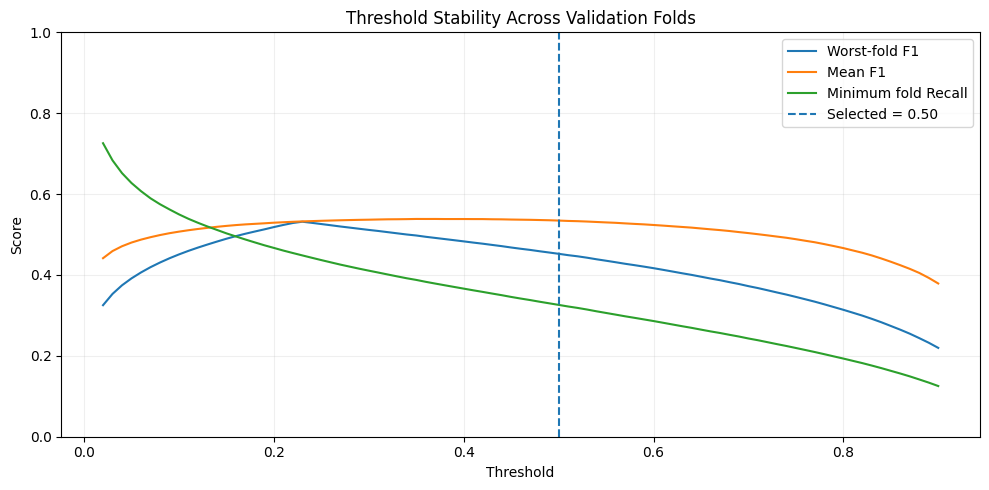

In [5]:
fig = stability_plot(fold_summary, 0.50)
plt.show()
